In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Personal/asteroid_project/data/processed/model_ready.csv')

In [3]:
df

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,Orbit_type,hazerdous
0,21.40,0.15,127.0,1.01,0.0,20.0,62.48070,244.79472,84.88190,0.55848,0.409179,0.737913,1.212828,10,3.979126,Apollo,1
1,19.83,0.15,1273.0,0.46,0.0,20.0,98.89528,191.01513,158.53021,4.15360,0.468938,0.362276,1.948839,4,1.581194,Amor,1
2,21.02,0.15,122.0,0.56,8.0,20.0,55.14514,315.45340,98.06173,11.29790,0.833937,0.604988,1.384537,1,2.589485,Apollo,1
3,19.82,0.15,67.0,0.42,0.0,16.0,259.42848,41.10016,101.09876,33.14882,0.259506,0.744528,1.205633,6,4.088311,Apollo,1
4,21.42,0.15,47.0,0.41,2.0,15.0,334.78938,5.05085,329.88433,10.46759,0.277851,0.642733,1.329788,4,2.874540,Apollo,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6186,17.50,0.15,117.0,0.86,0.0,24.0,200.80009,342.79875,46.54209,14.98348,0.215633,0.226925,2.662040,7,1.299104,MBA,0
6187,16.62,0.15,500.0,0.87,0.0,19.0,16.35079,314.34508,44.86460,15.29154,0.160287,0.270366,2.368650,13,1.378007,Phocaea,0
6188,12.43,0.15,2568.0,0.71,0.0,32.0,257.01445,165.81046,351.06621,5.36940,0.140744,0.123937,3.984140,23,1.143834,Hilda,0
6189,15.17,0.15,1665.0,0.84,0.0,30.0,63.43605,76.67384,168.76001,14.23635,0.127615,0.236817,2.587383,20,1.316266,MBA,0


In [4]:
df.describe()

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,hazerdous
count,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000,6191.000000
mean,18.672300,0.149990,323.044096,0.650695,1.119690,18.186400,177.529140,183.945577,172.571646,11.400914,0.312896,0.347747,2.434454,7.395090,2.447369,0.404620
std,2.131042,0.000763,681.662727,0.231991,2.189574,9.415373,104.405523,102.500505,103.703924,9.765695,0.230483,0.246205,2.486892,5.963914,12.755371,0.490858
min,3.090000,0.090000,4.000000,0.020000,0.000000,0.000000,0.082300,0.030960,0.038520,0.122980,0.001869,0.000762,0.630997,1.000000,1.000774,0.000000
25%,17.230000,0.150000,56.000000,0.450000,0.000000,12.000000,87.227870,96.351750,83.074970,4.767815,0.130041,0.214571,1.923363,3.000000,1.277897,0.000000
50%,18.480000,0.150000,123.000000,0.690000,0.000000,20.000000,175.296070,189.042100,165.864970,8.737070,0.218410,0.261602,2.421266,6.000000,1.360662,0.000000
75%,20.300000,0.150000,301.000000,0.840000,1.000000,22.000000,268.872630,272.303040,261.425605,14.616700,0.519628,0.369498,2.763260,11.000000,1.593349,1.000000
max,32.610000,0.150000,14552.000000,1.390000,9.000000,149.000000,359.892950,359.875000,359.961310,133.993190,0.966333,1.966359,118.684544,68.000000,595.063438,1.000000


In [5]:
df.shape

(6191, 17)

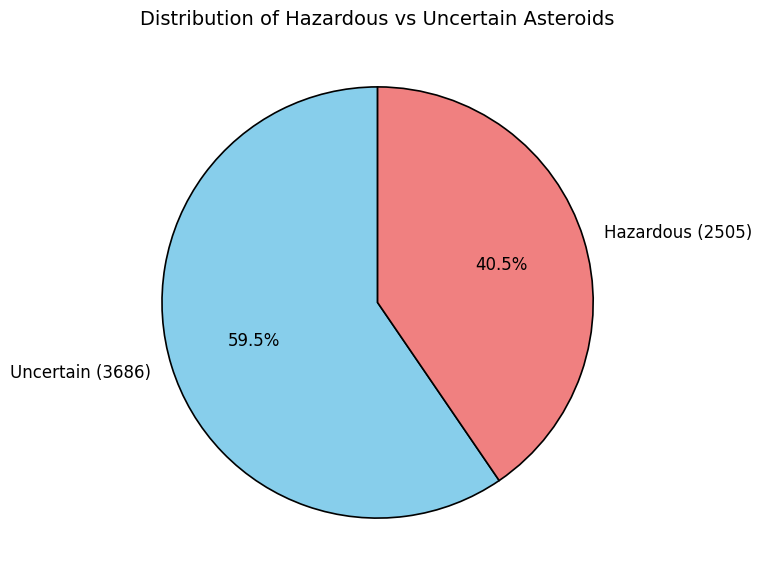

In [6]:
counts = df['hazerdous'].value_counts()
labels = [f'Uncertain ({counts[0]})', f'Hazardous ({counts[1]})']
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'k', 'linewidth':1.2}, textprops={'fontsize':12})
plt.title('Distribution of Hazardous vs Uncertain Asteroids', fontsize=14)
plt.show()

In [7]:
hazardous = df[df['hazerdous'] == 1]

uncertain = df[df['hazerdous'] == 0]

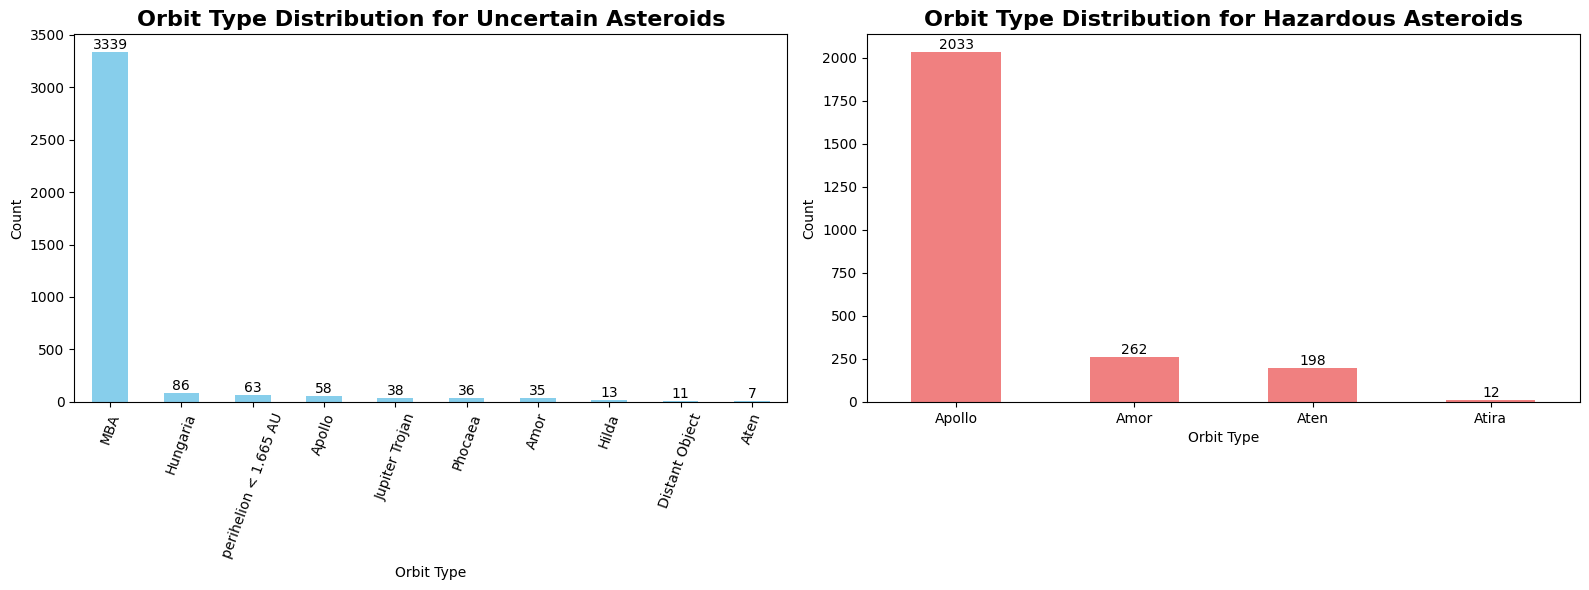

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


uncertain['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='skyblue'
)
axes[0].set_title('Orbit Type Distribution for Uncertain Asteroids',
                  fontweight='bold',
                  fontsize=16
                  )
axes[0].set_xlabel('Orbit Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=70)

hazardous['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='lightcoral'
)
axes[1].set_title('Orbit Type Distribution for Hazardous Asteroids',
                  fontweight='bold',
                  fontsize=16
                  )
axes[1].set_xlabel('Orbit Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, rotation=0)


plt.tight_layout()
plt.show()

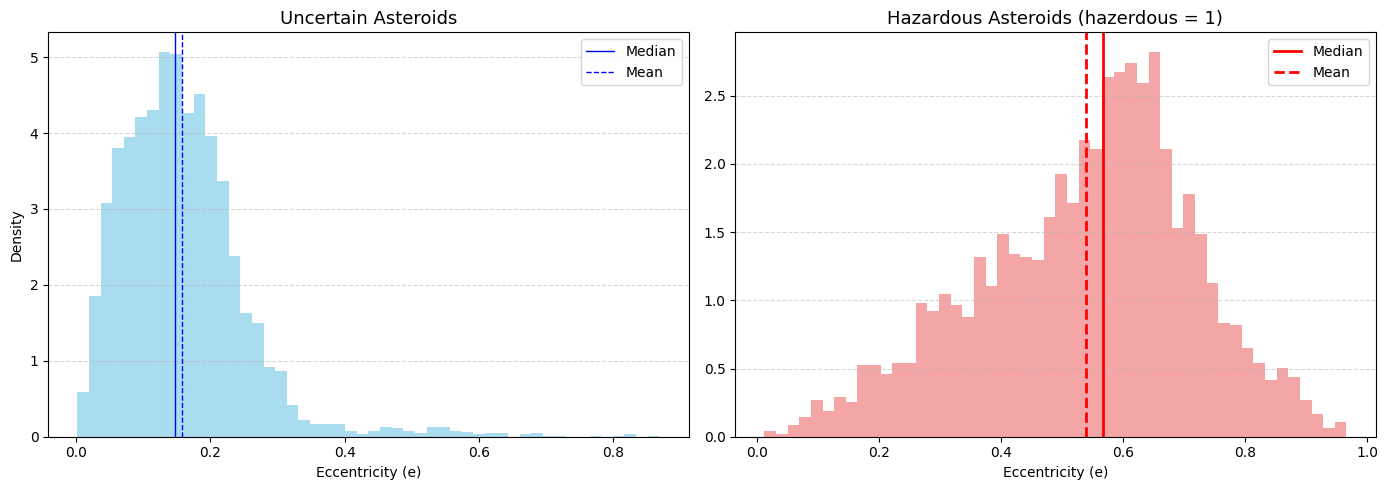

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(uncertain['e'], bins=50, alpha=0.7, color='skyblue', density=True)
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_xlabel('Eccentricity (e)')
axes[0].set_ylabel('Density')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0].axvline(uncertain['e'].median(), color='blue', linestyle='-', linewidth=1, label='Median')
axes[0].axvline(uncertain['e'].mean(), color='blue', linestyle='--', linewidth=1, label='Mean')
axes[0].legend()

axes[1].hist(hazardous['e'], bins=50, alpha=0.7, color='lightcoral', density=True)
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_xlabel('Eccentricity (e)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].axvline(hazardous['e'].median(), color='red', linestyle='-', linewidth=2, label='Median')
axes[1].axvline(hazardous['e'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()


<Axes: >

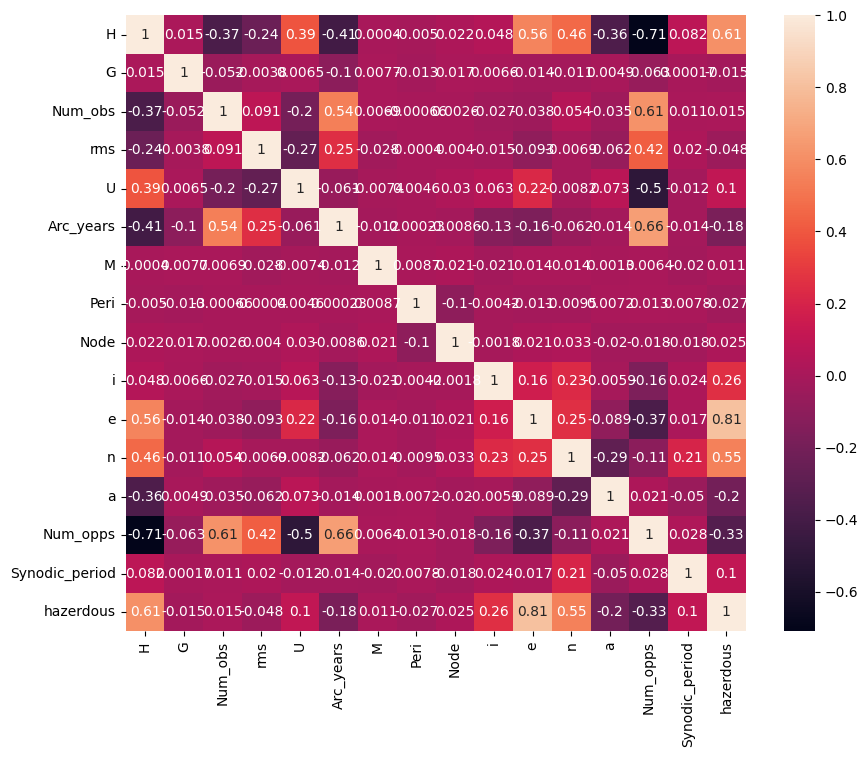

In [10]:
c = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(c, annot=True)

In [11]:
from sklearn.model_selection import train_test_split

#df_encoded = pd.get_dummies(df, columns=['Orbit_type'], drop_first=True)

#X = df_encoded.drop('hazerdous', axis=1)
#y = df_encoded['hazerdous']

df = df.drop('Orbit_type', axis=1)

X = df.drop('hazerdous', axis=1)
y = df['hazerdous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4952, 15)
Shape of X_test: (1239, 15)
Shape of y_train: (4952,)
Shape of y_test: (1239,)


In [12]:
from sklearn.preprocessing import StandardScaler

sample_frac = 0.1

X_train_small = X_train.sample(frac=sample_frac, random_state=42)
y_train_small = y_train.sample(frac=sample_frac, random_state=42)
X_test_small = X_test.sample(frac=sample_frac, random_state=42)
y_test_small = y_test.sample(frac=sample_frac, random_state=42)

scaler = StandardScaler()
X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_small_scaled = scaler.transform(X_test_small)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [14]:
models = [
    ('Logistic Regression', LogisticRegression(random_state=42, solver='liblinear')),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Support Vector Machine', SVC(probability=True, random_state=42))
]

accuracy_scores = {}
precision_scores = {}
recall_scores = {}
f1_scores = {}
roc_auc_scores = {}

for name, model in models:
    if name in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine']:
        # Use scaled small datasets
        model.fit(X_train_small_scaled, y_train_small)
        y_pred = model.predict(X_test_small_scaled)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_small_scaled)[:, 1]
        else:
            y_proba = None
    else:
        model.fit(X_train_small, y_train_small)
        y_pred = model.predict(X_test_small)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_small)[:, 1]
        else:
            y_proba = None

    accuracy_scores[name] = accuracy_score(y_test_small, y_pred)
    precision_scores[name] = precision_score(y_test_small, y_pred)
    recall_scores[name] = recall_score(y_test_small, y_pred)
    f1_scores[name] = f1_score(y_test_small, y_pred)
    roc_auc_scores[name] = roc_auc_score(y_test_small, y_proba) if y_proba is not None else 'N/A'

print("\nSummary of Model Performance (Small Sample)")
for name in accuracy_scores:
    print(f"{name}: Accuracy={accuracy_scores[name]:.4f}, Precision={precision_scores[name]:.4f}, "
          f"Recall={recall_scores[name]:.4f}, F1={f1_scores[name]:.4f}, ROC AUC={roc_auc_scores[name]}")



Summary of Model Performance (Small Sample)
Logistic Regression: Accuracy=0.9944, Precision=0.9865, Recall=1.0000, F1=0.9932, ROC AUC=0.9973280144513021
Decision Tree: Accuracy=0.9944, Precision=0.9980, Recall=0.9883, F1=0.9931, ROC AUC=0.9934423453259069
Random Forest: Accuracy=1.0000, Precision=1.0000, Recall=1.0000, F1=1.0000, ROC AUC=1.0
K-Nearest Neighbors: Accuracy=0.9911, Precision=0.9826, Recall=0.9961, F1=0.9893, ROC AUC=0.9987271779101524
Support Vector Machine: Accuracy=0.9960, Precision=0.9903, Recall=1.0000, F1=0.9951, ROC AUC=0.9999838713145954


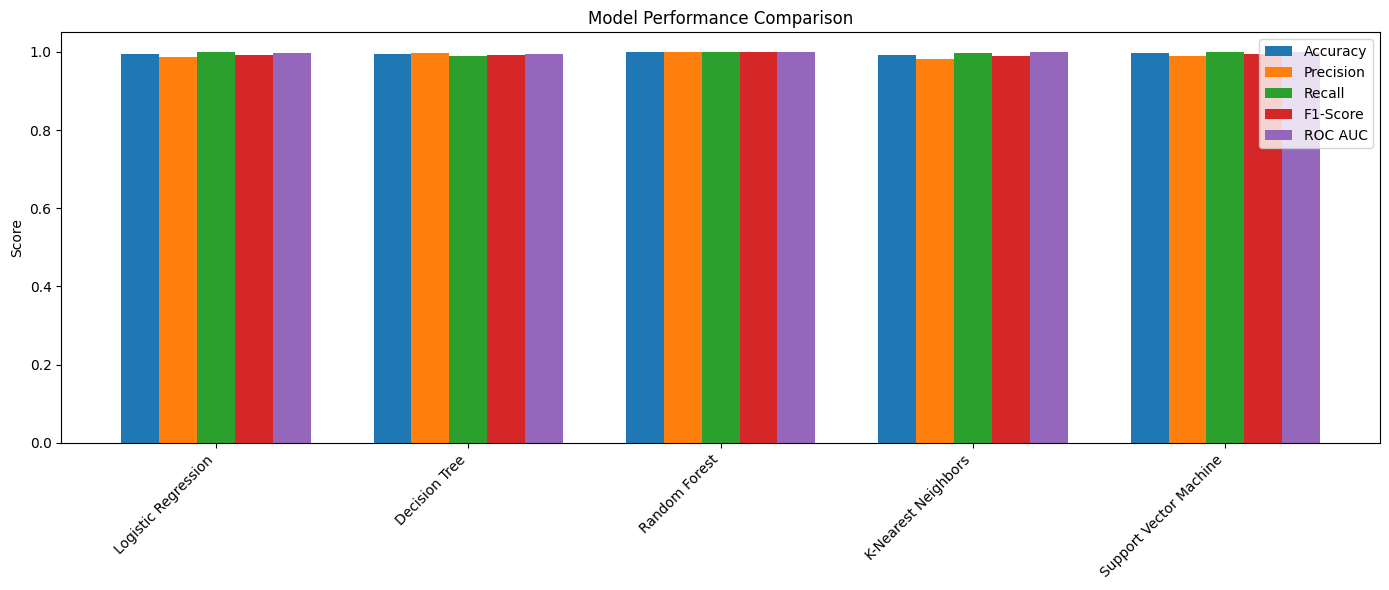

In [15]:
metrics_data = {
    'Model': list(accuracy_scores.keys()),
    'Accuracy': list(accuracy_scores.values()),
    'Precision': list(precision_scores.values()),
    'Recall': list(recall_scores.values()),
    'F1-Score': list(f1_scores.values()),
    'ROC AUC': [v if v != 'N/A' else np.nan for v in roc_auc_scores.values()]
}

metrics_df = pd.DataFrame(metrics_data)


labels = metrics_df['Model']
x = np.arange(len(labels))
width = 0.15

fig, ax = plt.subplots(figsize=(14,6))

ax.bar(x - 2*width, metrics_df['Accuracy'], width, label='Accuracy')
ax.bar(x - width, metrics_df['Precision'], width, label='Precision')
ax.bar(x, metrics_df['Recall'], width, label='Recall')
ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score')
ax.bar(x + 2*width, metrics_df['ROC AUC'], width, label='ROC AUC')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


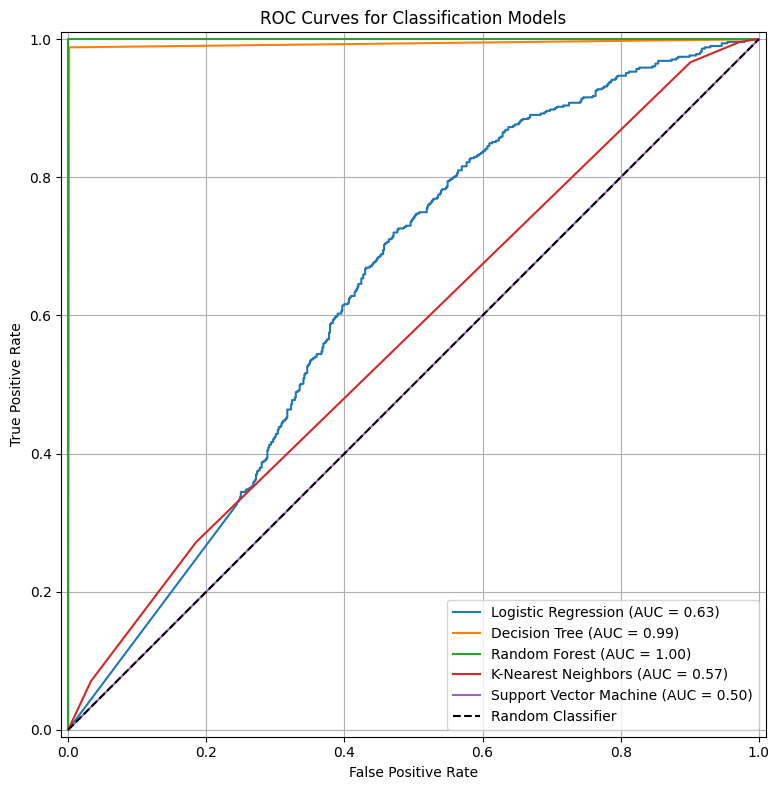

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


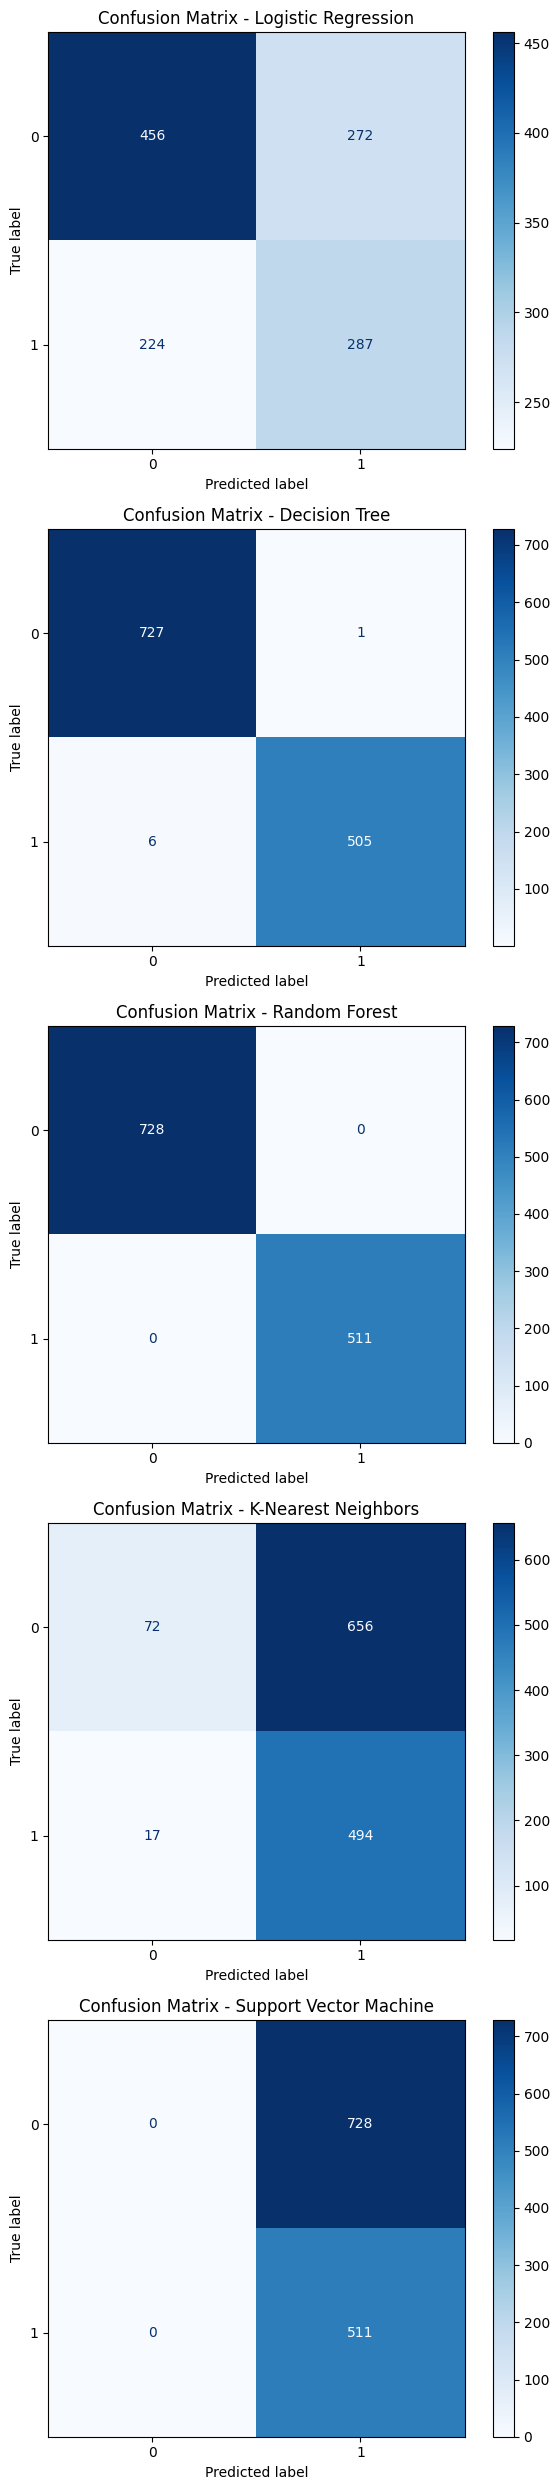

In [21]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay


plt.figure(figsize=(10, 8))
ax = plt.gca()
for name, model in models:
    if hasattr(model, "predict_proba") and roc_auc_scores[name] != 'N/A':
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
plt.title('ROC Curves for Classification Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(nrows=len(models), ncols=1, figsize=(6, 5 * len(models)))
if len(models) == 1:
    axes = [axes]

for i, (name, model) in enumerate(models):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix - {name}')
plt.tight_layout()
plt.show()

In [20]:
import joblib
from sklearn.ensemble import RandomForestClassifier

selected_model_name = 'Random Forest'
selected_model = RandomForestClassifier(n_estimators=100, random_state=42)

selected_model.fit(X_train_small, y_train_small)
y_pred = selected_model.predict(X_test_small)
y_proba = selected_model.predict_proba(X_test_small)[:, 1]

model_data = {
    'model': selected_model,
    'feature_names': X_train_small.columns.tolist()
}

joblib.dump(model_data, f'/content/drive/MyDrive/Colab Notebooks/Personal/asteroid_project/model.pkl')

['/content/drive/MyDrive/Colab Notebooks/Personal/asteroid_project/model.pkl']